# Transformada rapida de fourier

El método de la transformada r´apida de Fourier es una forma de c´alculo
simplificada de la TDF, fue dise˜nado utilizando las propiedades de la transformada y s´olo se puede aplicar a im´agenes cuyos tama˜nos sean potencia de
2 (es lo que permite simplificar m´as aun los c´alculos).
Eval´ue el rendimiento de FFT (Fast Fourier Transform) respecto de la TDF.
• Cargue una imagen y obtenga el tama˜no ´optimo (para filas y columnas)
al cual debe llevar la imagen para el c´alculo de la FFT.
• A partir de la imagen original genere una de tama˜no ´optimo (Nopt×Mopt)
agregando ceros.
• Genere una imagen cuyo tama˜no en filas y columnas sea 1px menor al
tama˜no ´optimo ((Nopt − 1) × (Mopt − 1)) agregando ceros.
• Calcule la TDF de las 3 im´agenes, visualice las magnitudes de las TDFs
y saque conclusiones, eval´ue el tiempo de c´omputo de cada una.
• ¿Qu´e efecto num´erico (objetivo) y a la vista (subjetivo) produce el agregado de ceros?

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import timeit

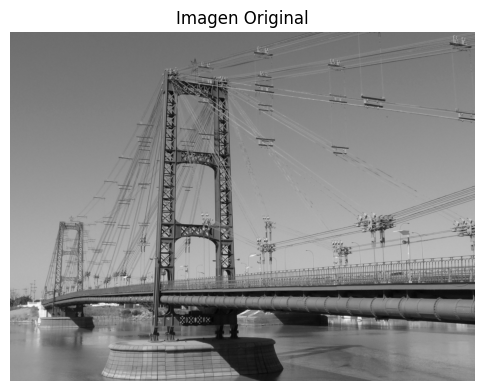

In [14]:
img = cv2.imread(
    "../Imagenes_cursado/puente.jpg",
    cv2.IMREAD_GRAYSCALE
)
plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title("Imagen Original")
plt.axis('off')
plt.show()

El tamaño optimo es el tamaño mas eficiente para calcular la DFT. En este caso no cambia por lo que el efecto no se veria

In [15]:
filas, cols = img.shape

print(f"Tamaño original: {filas} x {cols}")

Nopt = cv2.getOptimalDFTSize(filas)
Mopt = cv2.getOptimalDFTSize(cols)

print(f"Tamaño óptimo FFT: {Nopt} x {Mopt}") #en 

Tamaño original: 750 x 1000
Tamaño óptimo FFT: 750 x 1000


Para poder apreciar el efecto, le restamos 1 de dimenion en ambo ejes y vemos como influye

In [18]:
N_peor = Nopt - 1
M_peor = Mopt - 1

img_peor = cv2.copyMakeBorder(
    img,
    0, max(0, N_peor - filas),
    0, max(0, M_peor - cols),
    cv2.BORDER_CONSTANT,
    value=0
)

img_peor = img_peor[
    :N_peor,
    :M_peor
]

print(img_peor.shape)

(749, 999)


In [21]:
def calcular_fft(img):
    dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    mag = cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1])
    mag = 20 * np.log1p(mag)

    return mag


def medir_tiempo(img):
    def run():
        cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)

    return timeit.timeit(run, number=10)

In [22]:
Nopt = cv2.getOptimalDFTSize(filas)
Mopt = cv2.getOptimalDFTSize(cols)

# óptima
img_opt = cv2.copyMakeBorder(
    img,
    0, Nopt - filas,
    0, Mopt - cols,
    cv2.BORDER_CONSTANT,
    value=0
)

# peor caso
N_peor = Nopt - 1
M_peor = Mopt - 1

img_peor = cv2.copyMakeBorder(
    img,
    0, max(0, N_peor - filas),
    0, max(0, M_peor - cols),
    cv2.BORDER_CONSTANT,
    value=0
)

img_peor = img_peor[:N_peor, :M_peor]

In [23]:
mag_orig = calcular_fft(img)
mag_opt = calcular_fft(img_opt)
mag_peor = calcular_fft(img_peor)

t_orig = medir_tiempo(img)
t_opt = medir_tiempo(img_opt)
t_peor = medir_tiempo(img_peor)

print("TIEMPOS DE EJECUCIÓN (DFT)")
print("-" * 40)
print(f"Original : {t_orig:.6f} s")
print(f"Óptimo   : {t_opt:.6f} s")
print(f"Peor     : {t_peor:.6f} s")

TIEMPOS DE EJECUCIÓN (DFT)
----------------------------------------
Original : 0.061481 s
Óptimo   : 0.045247 s
Peor     : 0.149483 s


Vemos que si no tiene un tamaño optimo va peor

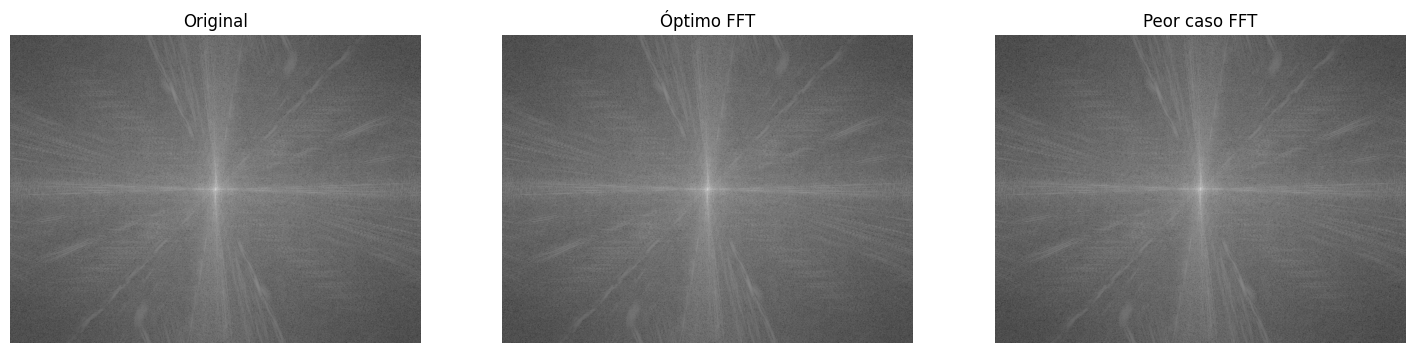

In [24]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(mag_orig, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mag_opt, cmap='gray')
plt.title("Óptimo FFT")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mag_peor, cmap='gray')
plt.title("Peor caso FFT")
plt.axis("off")

plt.show()

# probando un ejemplo que no tiene tamaño optimo

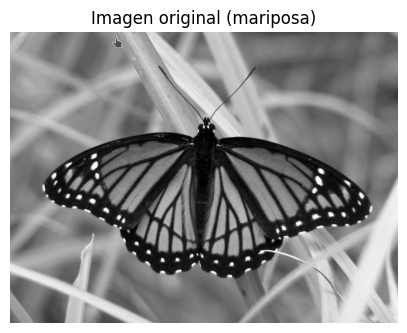

Tamaño original: (601, 799)
Tamaño óptimo: 625 x 800


In [34]:
img = cv2.imread("../Imagenes_cursado/mariposa02.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title("Imagen original (mariposa)")
plt.axis("off")
plt.show()

filas, cols = img.shape

print("Tamaño original:", img.shape)
Nopt = cv2.getOptimalDFTSize(filas)
Mopt = cv2.getOptimalDFTSize(cols)

print("Tamaño óptimo:", Nopt, "x", Mopt)

In [ ]:
img_opt = cv2.copyMakeBorder(
    img,
    0, Nopt - filas,
    0, Mopt - cols,
    cv2.BORDER_CONSTANT,
    value=0
)

In [36]:
mag_orig = calcular_fft(img)
mag_opt = calcular_fft(img_opt)

t_orig = medir_tiempo(img)
t_opt = medir_tiempo(img_opt)


print("\nTIEMPOS (DFT)")
print("-" * 40)
print(f"Original : {t_orig:.6f} s")
print(f"Óptimo   : {t_opt:.6f} s")




TIEMPOS (DFT)
----------------------------------------
Original : 0.118772 s
Óptimo   : 0.030860 s
